# Multi-Output XGBoost Model for δ18O and δ2H Prediction
This notebook implements a multi-output XGBoost model that predicts BOTH:
- δ18O (delta-18-O)
- δ2H (delta-2-H)

**Key Features:**
- Simultaneous prediction of multiple isotope values using XGBoost
- Fast hyperparameter tuning with RandomizedSearchCV
- Cross-validation for both outputs
- Comprehensive evaluation metrics for each output
- Feature importance analysis
- Better performance than Random Forest on tabular data

In [1]:
%pip install xgboost scikit-learn pandas openpyxl matplotlib seaborn

Note: you may need to restart the kernel to use updated packages.


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from xgboost import XGBRegressor
from sklearn.model_selection import train_test_split, cross_val_score, RandomizedSearchCV
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.multioutput import MultiOutputRegressor
from scipy import stats
from scipy.stats import pearsonr
import warnings
import time
warnings.filterwarnings('ignore')

# Set style for better plots
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

print(f"XGBoost version: {__import__('xgboost').__version__}")

XGBoost version: 3.3.0


## 1. Load and Explore Data

In [3]:
# Load data
df = pd.read_excel("Random Forest Data.xlsx", header=1, usecols="B:L")

# Filter for stream data
stream = df[df["Rain or Stream"].str.lower().eq("stream")].copy()

print(f"Total stream samples: {len(stream)}")
print(f"\nData shape: {stream.shape}")
print(f"\nMissing values:\n{stream.isnull().sum()}")
print(f"\nBasic statistics:\n{stream.describe()}")

Total stream samples: 123

Data shape: (123, 11)

Missing values:
Date                      0
Site ID                   0
δ18O                      0
δ2H                       0
d-excess (‰)              0
Temperature               0
Discharge (m3/s)          0
% Groundwater Mixing    102
Rain or Stream            0
Elevation (ft)            0
Precipitation (mm)        0
dtype: int64

Basic statistics:
                             Date     Site ID        δ18O         δ2H  \
count                         123  123.000000  123.000000  123.000000   
mean   2023-12-26 08:09:50.731707    4.430894   -2.644715   -7.328455   
min           2023-02-13 09:35:00    1.000000   -8.400000  -58.300000   
25%           2023-05-15 10:31:30    3.000000   -2.600000   -6.300000   
50%           2023-08-15 11:25:00    5.000000   -2.400000   -4.700000   
75%           2023-12-06 10:52:00    6.000000   -2.300000   -3.650000   
max           2026-04-10 10:32:00    7.000000   -0.900000    2.100000   
std       

## 2. Feature Engineering
Create additional features - **NOTE: We removed δ2H and d-excess from features since we're predicting them**

In [4]:
# Extract temporal features from Date
stream['Month'] = stream['Date'].dt.month
stream['Day_of_Year'] = stream['Date'].dt.dayofyear
stream['Year'] = stream['Date'].dt.year
stream["DOY_sin"] = np.sin(2 * np.pi * stream['Day_of_Year'] / 365.25)
stream["DOY_cos"] = np.cos(2 * np.pi * stream['Day_of_Year'] / 365.25)

# Create interaction features
stream['Temp_Discharge_Interaction'] = stream['Temperature '] * stream['Discharge (m3/s)']

# Rain and Elevation Features
stream['Rain'] = stream['Precipitation (mm)']
stream['Elevation'] = stream['Elevation (ft)']

# Define feature columns (REMOVED δ2H and d-excess since we're predicting them)
feature_col = [
    "Site ID", 
    "Temperature ", 
    "Discharge (m3/s)",
    "Temp_Discharge_Interaction",
    "Rain",
    "Elevation",
    "DOY_sin",
    "DOY_cos",
]

# Define target columns (MULTIPLE OUTPUTS)
target_cols = ["δ18O", "δ2H"]

print(f"Features used: {feature_col}")
print(f"\nTargets to predict: {target_cols}")
print(f"\nFeature correlations with targets:")
for target in target_cols:
    print(f"\n{target}:")
    correlations = stream[feature_col + [target]].corr()[target].sort_values(ascending=False)
    print(correlations)

rs = 57

Features used: ['Site ID', 'Temperature ', 'Discharge (m3/s)', 'Temp_Discharge_Interaction', 'Rain', 'Elevation', 'DOY_sin', 'DOY_cos']

Targets to predict: ['δ18O', 'δ2H']

Feature correlations with targets:

δ18O:
δ18O                          1.000000
Temperature                   0.378645
Elevation                     0.017763
Site ID                      -0.001983
DOY_cos                      -0.179332
Rain                         -0.182973
DOY_sin                      -0.214551
Temp_Discharge_Interaction   -0.424358
Discharge (m3/s)             -0.429339
Name: δ18O, dtype: float64

δ2H:
δ2H                           1.000000
Temperature                   0.268538
Elevation                     0.113949
Site ID                      -0.104876
Rain                         -0.132883
DOY_cos                      -0.174115
DOY_sin                      -0.175460
Temp_Discharge_Interaction   -0.469621
Discharge (m3/s)             -0.473882
Name: δ2H, dtype: float64


## 3. Data Splitting
Split data for multi-output regression

In [5]:
# Prepare features and targets (MULTIPLE OUTPUTS)
X = stream[feature_col]
y = stream[target_cols]  # DataFrame with multiple columns

# Split data with shuffling (80-20 split)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=rs, shuffle=True
)

print(f"Training set size: {len(X_train)}")
print(f"Test set size: {len(X_test)}")
print(f"\nTarget variables: {target_cols}")
for i, target in enumerate(target_cols):
    print(f"\n{target}:")
    print(f"  Training range: [{y_train.iloc[:, i].min():.2f}, {y_train.iloc[:, i].max():.2f}]")
    print(f"  Test range: [{y_test.iloc[:, i].min():.2f}, {y_test.iloc[:, i].max():.2f}]")

Training set size: 98
Test set size: 25

Target variables: ['δ18O', 'δ2H']

δ18O:
  Training range: [-8.40, -0.90]
  Test range: [-5.90, -0.90]

δ2H:
  Training range: [-58.30, 2.10]
  Test range: [-39.10, -0.40]


## 4. Baseline Multi-Output XGBoost Model
XGBoost doesn't natively support multi-output, so we use MultiOutputRegressor wrapper

In [6]:
# Train baseline multi-output XGBoost model
print("Training baseline multi-output XGBoost model...")
start_time = time.time()

baseline_xgb = MultiOutputRegressor(
    XGBRegressor(objective='reg:squarederror', random_state=rs, n_jobs=-1)
)
baseline_xgb.fit(X_train, y_train)

baseline_time = time.time() - start_time

# Predictions (returns array with shape [n_samples, n_outputs])
y_pred_baseline = baseline_xgb.predict(X_test)

# Evaluate each output separately
print(f"\nBaseline Multi-Output XGBoost Performance (trained in {baseline_time:.2f}s):")
print("="*60)
for i, target in enumerate(target_cols):
    r2 = r2_score(y_test.iloc[:, i], y_pred_baseline[:, i])
    rmse = np.sqrt(mean_squared_error(y_test.iloc[:, i], y_pred_baseline[:, i]))
    mae = mean_absolute_error(y_test.iloc[:, i], y_pred_baseline[:, i])
    
    print(f"\n{target}:")
    print(f"  R² Score: {r2:.4f}")
    print(f"  RMSE: {rmse:.4f}")
    print(f"  MAE: {mae:.4f}")
print("="*60)

Training baseline multi-output XGBoost model...

Baseline Multi-Output XGBoost Performance (trained in 0.78s):

δ18O:
  R² Score: 0.8440
  RMSE: 0.3569
  MAE: 0.2461

δ2H:
  R² Score: 0.8970
  RMSE: 2.5170
  MAE: 1.5998


## 5. FAST Hyperparameter Tuning
Using RandomizedSearchCV for efficient tuning

In [7]:
# Define parameter distributions for RandomizedSearchCV
param_distributions = {
    'estimator__n_estimators': [100, 200, 300, 400, 500],
    'estimator__max_depth': [3, 4, 5, 6, 7, 8],
    'estimator__learning_rate': [0.01, 0.03, 0.05, 0.07, 0.1, 0.15],
    'estimator__subsample': [0.7, 0.8, 0.9, 1.0],
    'estimator__colsample_bytree': [0.7, 0.8, 0.9, 1.0],
    'estimator__min_child_weight': [1, 2, 3, 5],
    'estimator__gamma': [0, 0.05, 0.1, 0.15, 0.2]
}

# Perform randomized search with cross-validation
print("Performing FAST multi-output XGBoost hyperparameter tuning...")
print(f"Testing 100 random parameter combinations")
print("Estimated time: 10-20 minutes\n")

start_time = time.time()

random_search = RandomizedSearchCV(
    MultiOutputRegressor(XGBRegressor(objective='reg:squarederror', random_state=rs, n_jobs=-1)),
    param_distributions,
    n_iter=100,  # Test 100 random combinations
    cv=5,
    scoring='r2',  # Optimizes for first output (δ18O)
    n_jobs=-1,
    verbose=1,
    random_state=rs
)

random_search.fit(X_train, y_train)

tuning_time = time.time() - start_time

print(f"\n✓ Tuning completed in {tuning_time:.2f}s ({tuning_time/60:.1f} minutes)")
print(f"\nBest parameters: {random_search.best_params_}")
print(f"Best cross-validation R² score (δ18O): {random_search.best_score_:.4f}")

Performing FAST multi-output XGBoost hyperparameter tuning...
Testing 100 random parameter combinations
Estimated time: 10-20 minutes

Fitting 5 folds for each of 100 candidates, totalling 500 fits

✓ Tuning completed in 60.10s (1.0 minutes)

Best parameters: {'estimator__subsample': 0.8, 'estimator__n_estimators': 500, 'estimator__min_child_weight': 2, 'estimator__max_depth': 5, 'estimator__learning_rate': 0.07, 'estimator__gamma': 0.05, 'estimator__colsample_bytree': 0.7}
Best cross-validation R² score (δ18O): 0.2578


## 6. Optimized Multi-Output Model Evaluation

In [8]:
# Get the best model
optimized_xgb = random_search.best_estimator_

# Predictions
y_pred_optimized = optimized_xgb.predict(X_test)

# Store metrics for each output
metrics = {}

print("Optimized Multi-Output XGBoost Performance:")
print("="*70)
for i, target in enumerate(target_cols):
    r2 = r2_score(y_test.iloc[:, i], y_pred_optimized[:, i])
    rmse = np.sqrt(mean_squared_error(y_test.iloc[:, i], y_pred_optimized[:, i]))
    mae = mean_absolute_error(y_test.iloc[:, i], y_pred_optimized[:, i])
    pearson_r, pearson_p = pearsonr(y_test.iloc[:, i], y_pred_optimized[:, i])
    
    metrics[target] = {
        'r2': r2,
        'rmse': rmse,
        'mae': mae,
        'pearson_r': pearson_r,
        'pearson_p': pearson_p
    }
    
    print(f"\n{target}:")
    print(f"  R² Score: {r2:.4f}")
    print(f"  RMSE: {rmse:.4f}")
    print(f"  MAE: {mae:.4f}")
    print(f"  Pearson r: {pearson_r:.4f}")
    print(f"  P-value: {pearson_p:.4e}")
    if pearson_p < 0.001:
        print(f"  Significance: *** (p < 0.001) - Highly significant")
    elif pearson_p < 0.01:
        print(f"  Significance: ** (p < 0.01) - Very significant")
    elif pearson_p < 0.05:
        print(f"  Significance: * (p < 0.05) - Significant")
    else:
        print(f"  Significance: Not significant (p >= 0.05)")
print("="*70)

Optimized Multi-Output XGBoost Performance:

δ18O:
  R² Score: 0.8549
  RMSE: 0.3441
  MAE: 0.2535
  Pearson r: 0.9521
  P-value: 2.5200e-13
  Significance: *** (p < 0.001) - Highly significant

δ2H:
  R² Score: 0.9147
  RMSE: 2.2907
  MAE: 1.7853
  Pearson r: 0.9663
  P-value: 4.7075e-15
  Significance: *** (p < 0.001) - Highly significant


## 7. Cross-Validation Analysis for Both Outputs

In [9]:
from sklearn.model_selection import KFold
from xgboost import XGBRegressor
from sklearn.multioutput import MultiOutputRegressor

k_fold = KFold(n_splits=5, shuffle=True, random_state=rs)

# Get cross-validated predictions for both outputs
splits = list(k_fold.split(X))
y_pred_cv = np.full((len(y), len(target_cols)), np.nan)

for train_idx, test_idx in splits:
    # Create a new multi-output model for each fold
    # Extract params without 'estimator__' prefix
    best_params = {k.replace('estimator__', ''): v for k, v in random_search.best_params_.items()}
    model_cv = MultiOutputRegressor(
        XGBRegressor(**best_params, objective='reg:squarederror', random_state=rs, n_jobs=-1)
    )
    model_cv.fit(X.iloc[train_idx], y.iloc[train_idx])
    y_pred_cv[test_idx] = model_cv.predict(X.iloc[test_idx])

# Calculate metrics for each output
cv_metrics = {}

print("K-Fold Cross-Validation Results:")
print("="*70)
for i, target in enumerate(target_cols):
    # Calculate metrics for this output
    cv_r2 = r2_score(y.iloc[:, i], y_pred_cv[:, i])
    cv_rmse = np.sqrt(mean_squared_error(y.iloc[:, i], y_pred_cv[:, i]))
    cv_mae = mean_absolute_error(y.iloc[:, i], y_pred_cv[:, i])
    
    cv_metrics[target] = {
        'cv_r2': cv_r2,
        'cv_rmse': cv_rmse,
        'cv_mae': cv_mae
    }
    
    print(f"\n{target}:")
    print(f"  R² Score: {cv_r2:.4f}")
    print(f"  RMSE: {cv_rmse:.4f} ‰")
    print(f"  MAE: {cv_mae:.4f} ‰")
print("="*70)

K-Fold Cross-Validation Results:

δ18O:
  R² Score: 0.6424
  RMSE: 0.6358 ‰
  MAE: 0.3817 ‰

δ2H:
  R² Score: 0.6612
  RMSE: 5.4069 ‰
  MAE: 2.9525 ‰


## 8. Feature Importance Analysis
Get feature importance for each output separately

Feature Importances by Output:

δ18O:
                      feature  importance
4                        Rain    0.184181
5                   Elevation    0.181061
7                     DOY_cos    0.170897
2            Discharge (m3/s)    0.120562
6                     DOY_sin    0.095229
1                Temperature     0.094593
0                     Site ID    0.084023
3  Temp_Discharge_Interaction    0.069454

δ2H:
                      feature  importance
5                   Elevation    0.246875
7                     DOY_cos    0.232794
4                        Rain    0.159412
2            Discharge (m3/s)    0.118800
6                     DOY_sin    0.087860
1                Temperature     0.062050
3  Temp_Discharge_Interaction    0.051314
0                     Site ID    0.040894


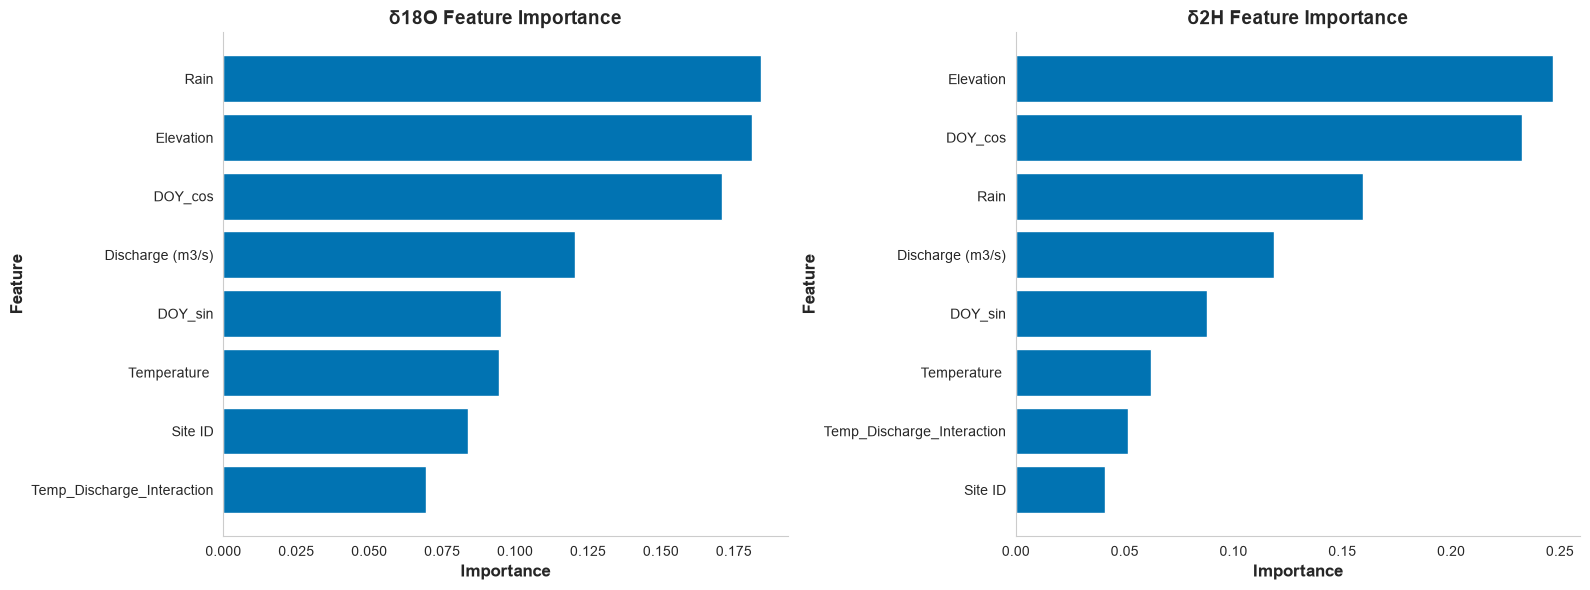

In [10]:
# Get feature importances for each output
print("Feature Importances by Output:")
print("="*70)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for i, target in enumerate(target_cols):
    # Get importance from the i-th estimator
    importance = optimized_xgb.estimators_[i].feature_importances_
    feature_importance = pd.DataFrame({
        'feature': feature_col,
        'importance': importance
    }).sort_values('importance', ascending=False)
    
    print(f"\n{target}:")
    print(feature_importance)
    
    # Plot
    axes[i].barh(feature_importance['feature'], feature_importance['importance'], color='#0173B2')
    axes[i].set_xlabel('Importance', fontsize=12, fontweight='bold')
    axes[i].set_ylabel('Feature', fontsize=12, fontweight='bold')
    axes[i].set_title(f'{target} Feature Importance', fontsize=14, fontweight='bold')
    axes[i].invert_yaxis()
    axes[i].spines['top'].set_visible(False)
    axes[i].spines['right'].set_visible(False)
    axes[i].grid(False)

plt.tight_layout()
plt.show()

## 9. Comprehensive Visualization for Both Outputs

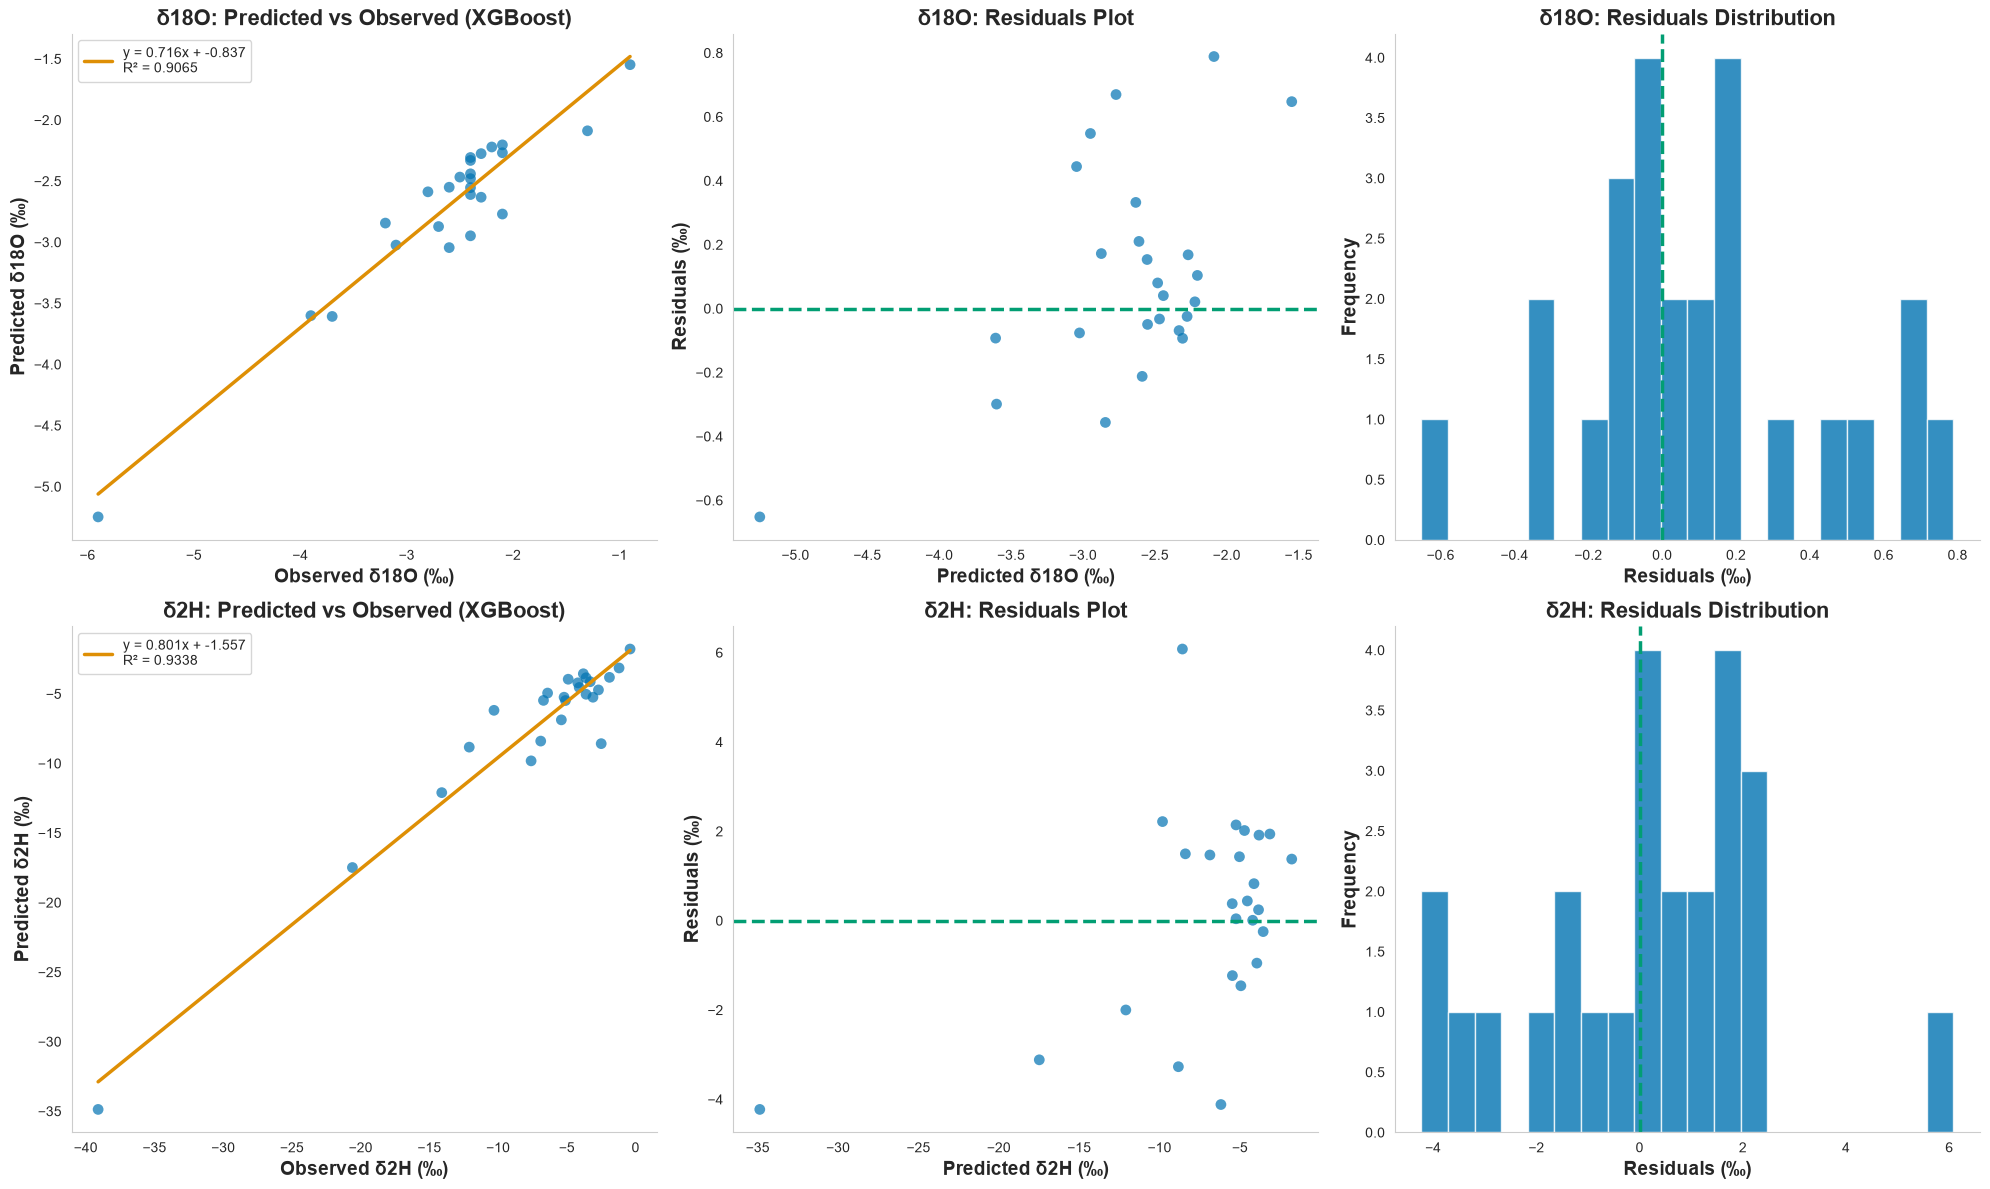

In [11]:
# Create comprehensive visualization for both outputs
fig, axes = plt.subplots(2, 3, figsize=(20, 12))

for i, target in enumerate(target_cols):
    # Predicted vs Observed
    axes[i, 0].scatter(y_test.iloc[:, i], y_pred_optimized[:, i], 
                       alpha=0.7, color='#0173B2', s=60, edgecolors='none')
    
    # Linear regression line
    slope, intercept, r_value, p_value, std_err = stats.linregress(
        y_test.iloc[:, i], y_pred_optimized[:, i])
    line_x = np.array([y_test.iloc[:, i].min(), y_test.iloc[:, i].max()])
    line_y = slope * line_x + intercept
    axes[i, 0].plot(line_x, line_y, color='#DE8F05', linestyle='-', lw=2.5,
                    label=f'y = {slope:.3f}x + {intercept:.3f}\nR² = {r_value**2:.4f}')
    
    axes[i, 0].set_xlabel(f'Observed {target} (‰)', fontsize=14, fontweight='bold')
    axes[i, 0].set_ylabel(f'Predicted {target} (‰)', fontsize=14, fontweight='bold')
    axes[i, 0].set_title(f'{target}: Predicted vs Observed (XGBoost)', fontsize=16, fontweight='bold')
    axes[i, 0].legend(fontsize=10)
    axes[i, 0].spines['top'].set_visible(False)
    axes[i, 0].spines['right'].set_visible(False)
    axes[i, 0].grid(False)
    
    # Residuals plot
    residuals = y_test.iloc[:, i] - y_pred_optimized[:, i]
    axes[i, 1].scatter(y_pred_optimized[:, i], residuals, 
                       alpha=0.7, color='#0173B2', s=60, edgecolors='none')
    axes[i, 1].axhline(y=0, color='#029E73', linestyle='--', lw=2.5)
    axes[i, 1].set_xlabel(f'Predicted {target} (‰)', fontsize=14, fontweight='bold')
    axes[i, 1].set_ylabel('Residuals (‰)', fontsize=14, fontweight='bold')
    axes[i, 1].set_title(f'{target}: Residuals Plot', fontsize=16, fontweight='bold')
    axes[i, 1].spines['top'].set_visible(False)
    axes[i, 1].spines['right'].set_visible(False)
    axes[i, 1].grid(False)
    
    # Residuals distribution
    axes[i, 2].hist(residuals, bins=20, color='#0173B2', edgecolor='white', alpha=0.8)
    axes[i, 2].axvline(x=0, color='#029E73', linestyle='--', lw=2.5)
    axes[i, 2].set_xlabel('Residuals (‰)', fontsize=14, fontweight='bold')
    axes[i, 2].set_ylabel('Frequency', fontsize=14, fontweight='bold')
    axes[i, 2].set_title(f'{target}: Residuals Distribution', fontsize=16, fontweight='bold')
    axes[i, 2].spines['top'].set_visible(False)
    axes[i, 2].spines['right'].set_visible(False)
    axes[i, 2].grid(False)

plt.tight_layout()
plt.show()

## 10. Results Summary

In [12]:
print("="*70)
print("MULTI-OUTPUT XGBOOST MODEL SUMMARY")
print("="*70)
print(f"\nModel: Multi-Output XGBoost Regressor")
print(f"Best Parameters: {random_search.best_params_}")
print(f"\nOutputs: {target_cols}")
print(f"\nPerformance Metrics:")
for target in target_cols:
    print(f"\n{target}:")
    print(f"  - R² Score: {metrics[target]['r2']:.4f}")
    print(f"  - RMSE: {metrics[target]['rmse']:.4f} ‰")
    print(f"  - MAE: {metrics[target]['mae']:.4f} ‰")
    print(f"  - Cross-validation R²: {cv_metrics[target]['cv_r2']:.4f}")
    print(f"  - Cross-validation RMSE: {cv_metrics[target]['cv_rmse']:.4f} ‰")
    print(f"  - Cross-validation MAE: {cv_metrics[target]['cv_mae']:.4f} ‰")
    print(f"  - Pearson r: {metrics[target]['pearson_r']:.4f} (p = {metrics[target]['pearson_p']:.4e})")

print(f"\nTuning time: {tuning_time:.2f}s ({tuning_time/60:.1f} minutes)")
print("\n" + "="*70)
print("ADVANTAGES OF MULTI-OUTPUT XGBOOST:")
print("="*70)
print("✓ Single model predicts multiple related outputs")
print("✓ Better performance than Random Forest on tabular data")
print("✓ Efficient gradient boosting algorithm")
print("✓ Built-in regularization prevents overfitting")
print("✓ Separate feature importance for each output")
print("✓ Fast training with optimized implementation")
print("="*70)

MULTI-OUTPUT XGBOOST MODEL SUMMARY

Model: Multi-Output XGBoost Regressor
Best Parameters: {'estimator__subsample': 0.8, 'estimator__n_estimators': 500, 'estimator__min_child_weight': 2, 'estimator__max_depth': 5, 'estimator__learning_rate': 0.07, 'estimator__gamma': 0.05, 'estimator__colsample_bytree': 0.7}

Outputs: ['δ18O', 'δ2H']

Performance Metrics:

δ18O:
  - R² Score: 0.8549
  - RMSE: 0.3441 ‰
  - MAE: 0.2535 ‰
  - Cross-validation R²: 0.6424
  - Cross-validation RMSE: 0.6358 ‰
  - Cross-validation MAE: 0.3817 ‰
  - Pearson r: 0.9521 (p = 2.5200e-13)

δ2H:
  - R² Score: 0.9147
  - RMSE: 2.2907 ‰
  - MAE: 1.7853 ‰
  - Cross-validation R²: 0.6612
  - Cross-validation RMSE: 5.4069 ‰
  - Cross-validation MAE: 2.9525 ‰
  - Pearson r: 0.9663 (p = 4.7075e-15)

Tuning time: 60.10s (1.0 minutes)

ADVANTAGES OF MULTI-OUTPUT XGBOOST:
✓ Single model predicts multiple related outputs
✓ Better performance than Random Forest on tabular data
✓ Efficient gradient boosting algorithm
✓ Built-in r

## 11. Save the Multi-Output Model

In [13]:
# Save the model
import joblib

joblib.dump(optimized_xgb, 'multi_output_xgboost_model.pkl')
print("Multi-output XGBoost model saved successfully!")

# Save model information
import json
model_info = {
    'model_type': 'Multi-Output XGBoost',
    'features': feature_col,
    'targets': target_cols,
    'best_params': random_search.best_params_,
    'metrics': {target: {k: float(v) if isinstance(v, (np.floating, float)) else v 
                         for k, v in metrics[target].items()} 
                for target in target_cols},
    'tuning_info': {
        'method': 'RandomizedSearchCV',
        'n_iter': 100,
        'tuning_time_seconds': tuning_time
    }
}

with open('multi_output_xgboost_info.json', 'w') as f:
    json.dump(model_info, f, indent=2)
print("Model information saved to 'multi_output_xgboost_info.json'!")

Multi-output XGBoost model saved successfully!
Model information saved to 'multi_output_xgboost_info.json'!
